# End-to-End ML Pipeline: Tesla Sales and Production Data (2015-2025)
This notebook covers:
1. Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Regression Modeling
5. Hyperparameter Tuning
6. Time Series Forecasting

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Exploratory Data Analysis (EDA)

In [2]:
# Basic Info
print(df.info())

# Summary Statistics
display(df.describe())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB
None


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


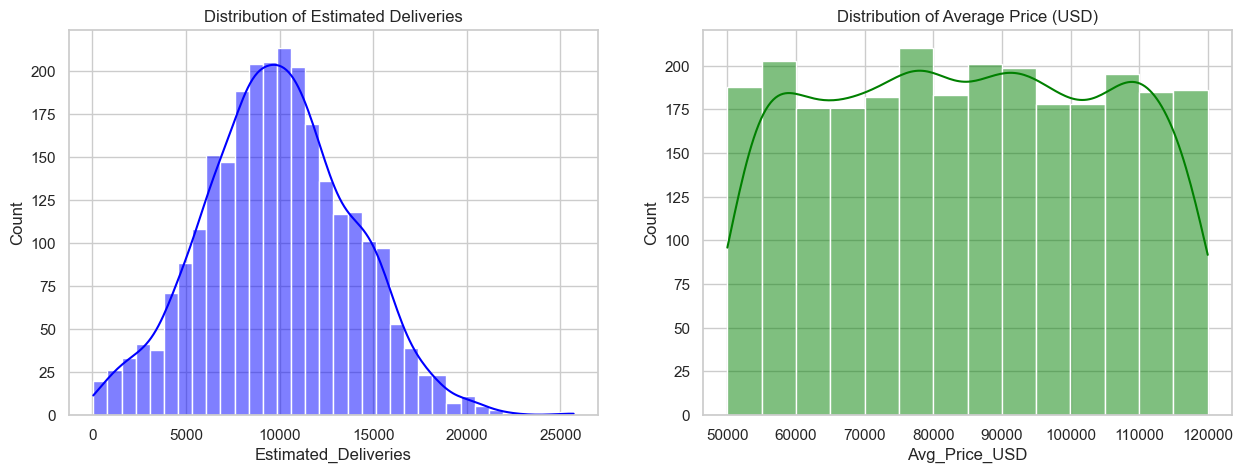

In [3]:
# Univariate Analysis: Target Variables Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Estimated Deliveries')

sns.histplot(df['Avg_Price_USD'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Average Price (USD)')
plt.show()

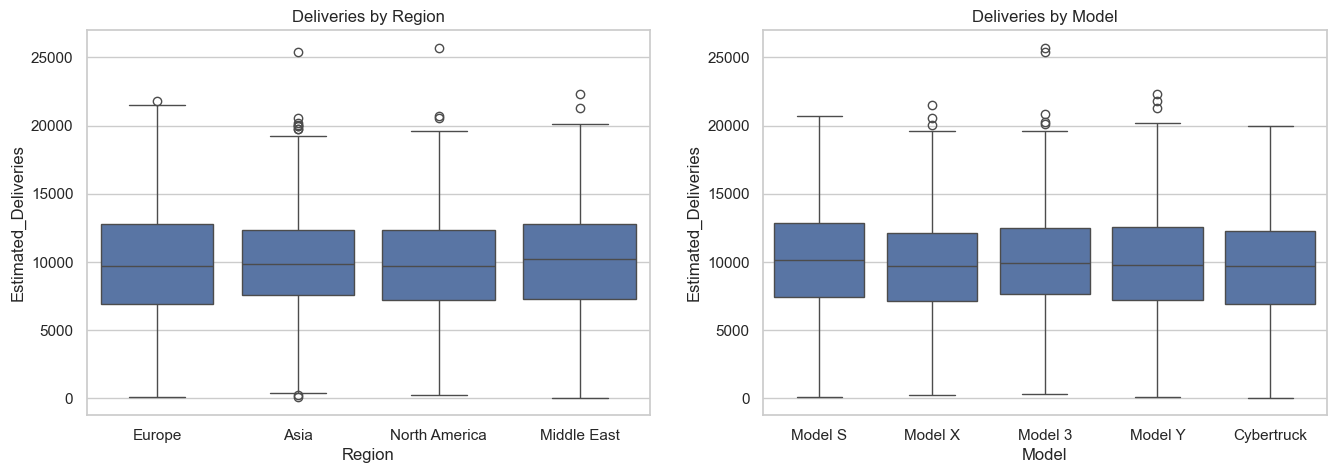

In [4]:
# Bivariate Analysis: Deliveries by Region and Model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', ax=axes[0])
axes[0].set_title('Deliveries by Region')

sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', ax=axes[1])
axes[1].set_title('Deliveries by Model')
plt.show()

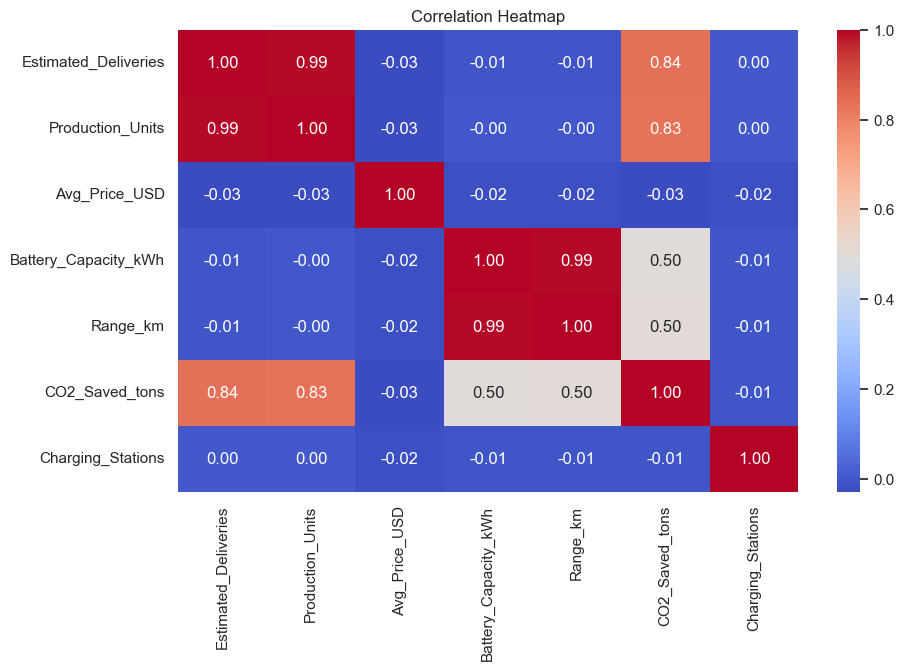

In [5]:
# Correlation Heatmap for numerical features
numerical_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 
                  'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocessing & Feature Engineering

In [6]:
# Create a proper DateTime index for Time Series analysis later
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

# Feature Engineering: Extract Quarter
df['Quarter'] = df['Date'].dt.quarter

# We will predict 'Estimated_Deliveries'. 
# Let's drop highly correlated/leaky features like 'Production_Units' and 'CO2_Saved_tons' for the regression task,
# or we can keep them if we assume we know them. Usually, production is closely tied to deliveries.
# To make it a realistic predictive model, let's predict Deliveries based on Model, Region, Price, and Time.

features = ['Year', 'Month', 'Quarter', 'Region', 'Model', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
target = 'Estimated_Deliveries'

X = df[features]
y = df[target]

# Train-Test Split (Chronological split is better for time-series, but we use standard split for regression part)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline
numeric_features = ['Year', 'Month', 'Quarter', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
categorical_features = ['Region', 'Model']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

## 4. Regression Modeling

In [7]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:.2f} | R2: {r2:.4f}")

Linear Regression -> RMSE: 3888.67 | R2: -0.0093
Random Forest -> RMSE: 3948.95 | R2: -0.0408
XGBoost -> RMSE: 4351.22 | R2: -0.2637


## 5. Hyperparameter Tuning (XGBoost)
XGBoost typically performs well, let's tune its hyperparameters.

In [8]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42, objective='reg:squarederror'))
])

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

y_pred_best = best_model.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print(f"Tuned XGBoost -> RMSE: {best_rmse:.2f} | R2: {best_r2:.4f}")

Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 50}
Tuned XGBoost -> RMSE: 3868.53 | R2: 0.0012


## 6. Time Series Forecasting
We will forecast the total Monthly Deliveries globally using ARIMA.

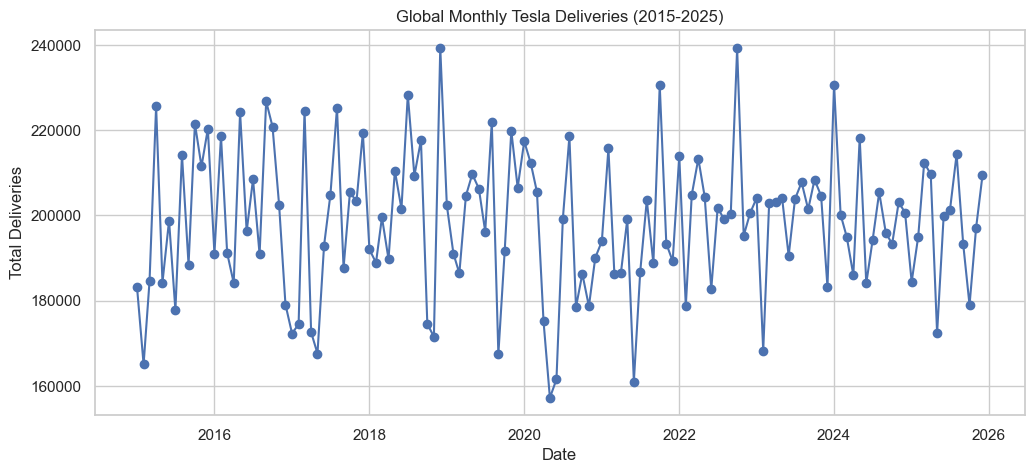

In [ ]:
# Aggregate deliveries by month globally
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_data.set_index('Date', inplace=True)

# Plot historical data
plt.figure(figsize=(12, 5))
plt.plot(ts_data.index, ts_data['Estimated_Deliveries'], marker='o', linestyle='-')
plt.title('Global Monthly Tesla Deliveries (2015-2025)')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.show()

In [ ]:
# Fit ARIMA Model
# Note: For a production system, p,d,q should be tuned (e.g., using pmdarima). Here we use a baseline (1, 1, 1)
model_arima = ARIMA(ts_data['Estimated_Deliveries'], order=(1, 1, 1))
results_arima = model_arima.fit()

print(results_arima.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sun, 17 May 2026   AIC                           2983.269
Time:                          20:53:54   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

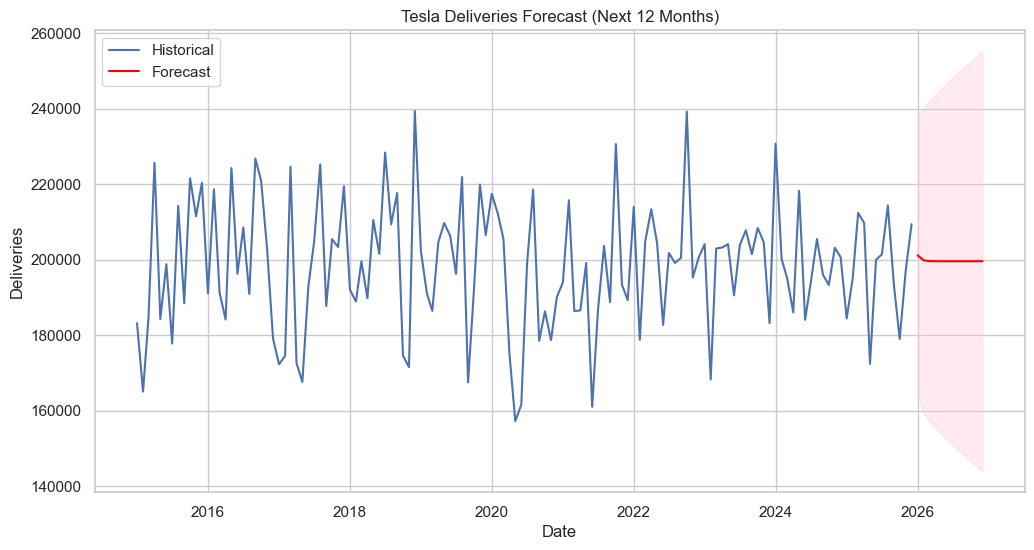

In [ ]:
# Forecast next 12 months
forecast_steps = 12
forecast = results_arima.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(ts_data.index, ts_data['Estimated_Deliveries'], label='Historical')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Tesla Deliveries Forecast (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.show()

# Pipeline Complete!
I successfully processed the data, explored patterns, engineered features, built predictive models, tuned hyperparameters, and performed time-series forecasting.